# 🛒 Tema 26: Clustering Jerárquico y PCA (Componentes Principales)

¡Bienvenido/a al Aprendizaje No Supervisado!

Hasta ahora, en algoritmos como Regresión Logística o Árboles, le dábamos al modelo las "respuestas correctas" (ej. "Este paciente tomó la Droga A"). Pero, ¿qué pasa cuando tenemos miles de clientes de una tienda y simplemente queremos saber "qué tipos de clientes existen" sin tener etiquetas previas? 

Para descubrir patrones ocultos utilizaremos el **Clustering (Agrupamiento)**.

## 🚀 Contenido del Cuaderno

1. **Teoría del Clustering:** Método Jerárquico, Distancia Euclidiana y Escala de Ward.
2. **Reducción de Dimensiones:** ¿Qué es el Análisis de Componentes Principales (PCA)?
3. **Proyecto Práctico (Amazon):** Sistema de Recomendación de Productos.
4. **Análisis Visual:** Creación e interpretación de un **Dendrograma**.
5. **Nivel Pro:** Visualización de Clústeres en 2D usando PCA.
6. **Conclusión de Negocio:** Recomendaciones personalizadas para clientes.
7. **Glosario Técnico.**

---
> **Instrucciones:** Ejecuta las celdas de forma secuencial. Asegúrate de tener el archivo `Amazon.xlsx` en tu directorio de trabajo.

## 1. Fundamentos: ¿Cómo agrupa la Inteligencia Artificial?

Imagina que cada cliente es un punto en un mapa.
1. **Clustering Aglomerativo (Bottom-up):** El algoritmo comienza asumiendo que cada cliente es su propio "grupo aislado". Luego, busca a los dos clientes más parecidos y los une. Luego une ese pequeño grupo con el siguiente más parecido, y así sucesivamente hasta que todos forman un solo mega-grupo.
2. **Distancia Euclidiana:** Es la regla matemática para medir "qué tan parecidos" son dos clientes. Si ambos le dieron 5 estrellas al mismo producto, su distancia en el mapa es corta.
3. **Escala de Ward (Ward's Linkage):** Es el método más eficiente para unir grupos. En lugar de solo medir distancias, Ward une a los clientes buscando que la "varianza" (el desorden) dentro del nuevo grupo sea la menor posible. Crea clústeres muy compactos y homogéneos.

El resultado de estas uniones escalonadas se visualiza en un **Dendrograma** (un diagrama en forma de árbol genealógico).

## 2. Análisis de Componentes Principales (PCA)

Nuestra base de datos de Amazon tiene 9 columnas (Velocidad de entrega, Precio, Calidad, etc.). Esto significa que los clientes viven en un espacio matemático de **9 dimensiones**. ¡El cerebro humano no puede visualizar algo en 9D!

Para poder graficar a los clientes en un plano X, Y (2 dimensiones), utilizamos **PCA**. 
El PCA es una técnica de álgebra lineal que "aplasta" las 9 dimensiones originales y las resume en 2 "Componentes Principales" (nuevas variables no correlacionadas) perdiendo la menor cantidad de información posible. Esto nos permitirá ver claramente cómo se separan los grupos.

---
## 📝 Proyecto Práctico: Segmentación de Clientes Amazon

**Objetivo de Negocio:**
Se nos ha entregado un archivo (`Amazon.xlsx`) con los promedios de evaluación de 100 clientes respecto a diversos productos y servicios de Amazon. 

Nuestro trabajo es crear un **Sistema de Recomendación**. Si logramos agrupar a los clientes con gustos idénticos en un mismo "Clúster", podremos recomendarle a la cliente **Salomé** lo que compraron otros clientes de su mismo grupo. Haremos lo mismo para **Stephanía** y **Lydia**.

**Paso 1: Ingesta y Estandarización de Datos**
Dado que el Clustering se basa en medir distancias geométricas, es *obligatorio* normalizar los datos. Si no lo hacemos, una columna con números grandes (ej. Precio = 500) dominará falsamente sobre una con números pequeños (ej. Estrellas = 5).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar la base de datos
df_amazon = pd.read_excel("Amazon.xlsx")

# 2. Limpieza y preparación
# Renombramos la primera columna sin nombre a 'Cliente' y la convertimos en el índice
df_amazon.rename(columns={'Unnamed: 0': 'Cliente'}, inplace=True)
df_amazon.set_index('Cliente', inplace=True)

# 3. Estandarización / Normalización de los datos (Paso Crítico)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_amazon)

print("=== Base de Datos Preparada y Escalada ===")
print(f"Total de clientes: {df_amazon.shape[0]}")
print(f"Total de variables de evaluación: {df_amazon.shape[1]}")
display(df_amazon.head(3))

=== Base de Datos Preparada y Escalada ===
Total de clientes: 100
Total de variables de evaluación: 9


,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
Cliente,,,,,,,,,
Adam,205,3,345,235,24,23,26,21,17
Anna,9,15,315,33,25,4,42,215,28
Bernard,17,26,285,3,43,27,41,26,33


### Paso 2: Creación del Dendrograma
Utilizaremos la librería `SciPy` para calcular las distancias entre clientes utilizando la métrica Euclidiana y el método de agrupamiento de **Ward**. Luego, dibujaremos el árbol para descubrir visualmente cuál es el número óptimo de clústeres.

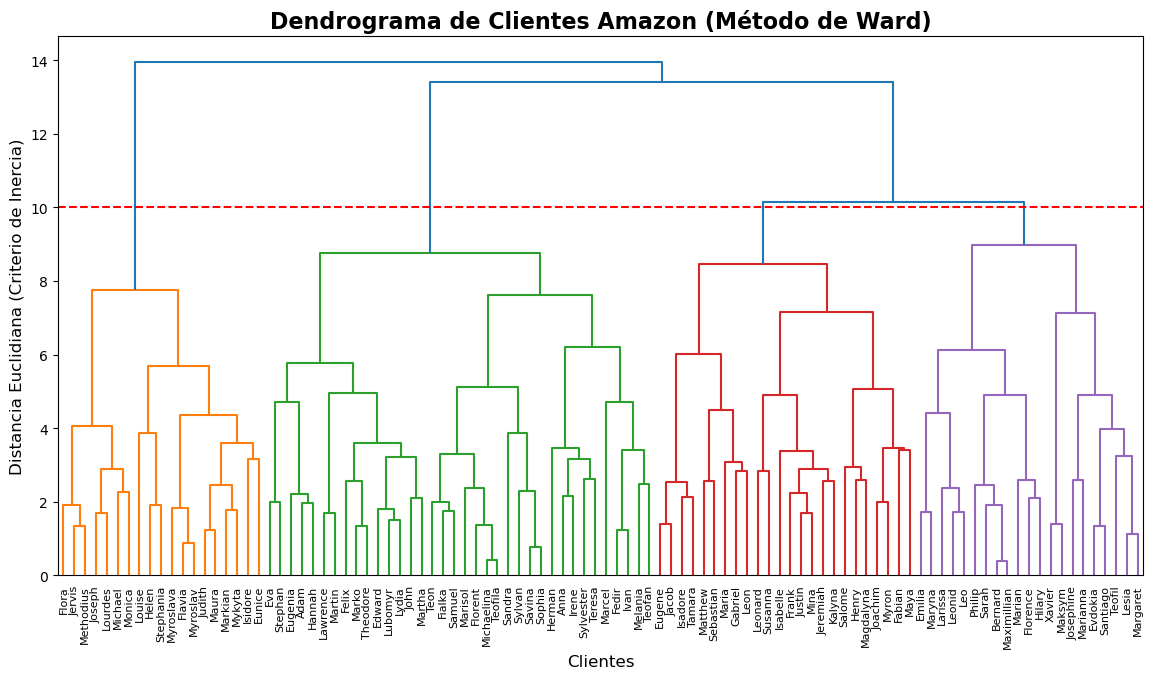

🔍 ANÁLISIS DEL DENDROGRAMA:
Si trazamos un corte horizontal en la distancia Y=10 (línea roja), interceptamos 4 líneas verticales.
Esto indica matemáticamente que el número óptimo de segmentos (clústeres) para estos clientes es 4.


In [3]:
# 1. Cálculo de la matriz de enlace (Linkage) usando el método de Ward
matriz_distancias = linkage(datos_escalados, method='ward', metric='euclidean')

# 2. Renderizado del Dendrograma
plt.figure(figsize=(14, 7))
dendrogram(matriz_distancias, 
           labels=df_amazon.index,
           leaf_rotation=90, 
           leaf_font_size=8,
           color_threshold=10) # El umbral de color nos ayuda a pintar los grupos resultantes

plt.title('Dendrograma de Clientes Amazon (Método de Ward)', fontsize=16, fontweight='bold')
plt.xlabel('Clientes', fontsize=12)
plt.ylabel('Distancia Euclidiana (Criterio de Inercia)', fontsize=12)

# Trazamos una línea horizontal imaginaria para "cortar" el árbol en 4 grupos principales
plt.axhline(y=10, color='r', linestyle='--')
plt.show()

print("🔍 ANÁLISIS DEL DENDROGRAMA:")
print("Si trazamos un corte horizontal en la distancia Y=10 (línea roja), interceptamos 4 líneas verticales.")
print("Esto indica matemáticamente que el número óptimo de segmentos (clústeres) para estos clientes es 4.")

### Paso 3: Análisis de Componentes Principales (PCA) y Asignación de Clústeres
Ahora que sabemos que hay 4 grupos de comportamiento en Amazon, usaremos `AgglomerativeClustering` de Scikit-Learn para etiquetar a cada cliente con un número (0, 1, 2 o 3).

Posteriormente, aplicaremos **PCA** para reducir las 9 columnas de evaluaciones a solo 2 Componentes Principales y graficaremos el resultado.

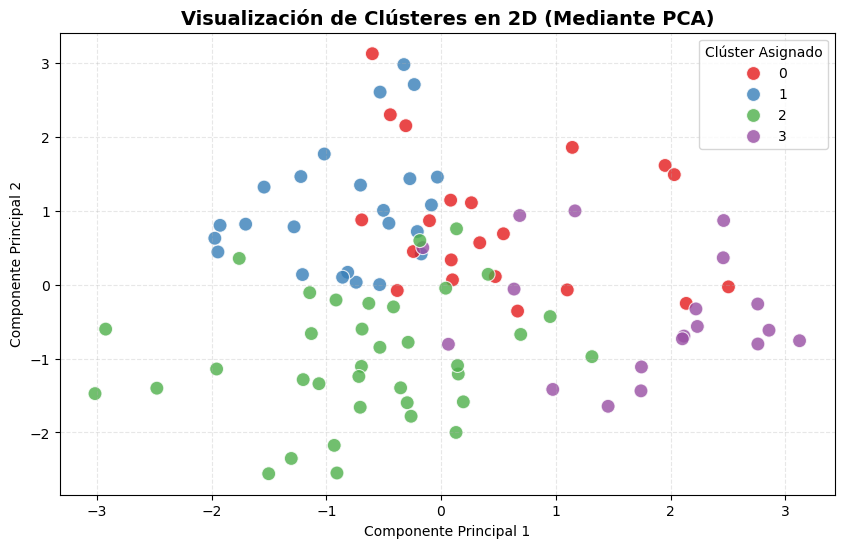

✅ Segmentación completada. Cada cliente pertenece ahora a un grupo con patrones de evaluación matemáticamente similares.


In [4]:
# 1. Instanciamos y entrenamos el algoritmo de Clustering
algoritmo_clustering = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
etiquetas_clusters = algoritmo_clustering.fit_predict(datos_escalados)

# Añadimos la etiqueta al dataframe original para análisis de negocio
df_amazon['Cluster'] = etiquetas_clusters

# 2. Reducción de dimensionalidad con PCA
pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(datos_escalados)

# 3. Gráfica 2D de los Segmentos de Clientes
plt.figure(figsize=(10, 6))
sns.scatterplot(x=componentes_principales[:, 0], 
                y=componentes_principales[:, 1], 
                hue=etiquetas_clusters, 
                palette='Set1', 
                s=100, alpha=0.8)

plt.title('Visualización de Clústeres en 2D (Mediante PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Clúster Asignado')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("✅ Segmentación completada. Cada cliente pertenece ahora a un grupo con patrones de evaluación matemáticamente similares.")

## 💡 Resultados de Negocio: Sistema de Recomendación

Para responder a las preguntas de la dirección sobre qué recomendarle a **Salomé**, **Stephanía** y **Lydia**, utilizaremos la lógica del Clustering: *"Dime con quién te agrupaste, y te recomendaré lo que ellos compraron"*.

In [6]:
# Función para buscar "Vecinos de Clúster" (pares con gustos similares)
def generar_recomendacion(nombre_cliente):
    # Verificamos que el cliente exista en la base
    if nombre_cliente not in df_amazon.index:
        return f"El cliente {nombre_cliente} no se encuentra en la base de datos."
    
    # 1. Identificamos a qué clúster pertenece el cliente objetivo
    mi_cluster = df_amazon.loc[nombre_cliente, 'Cluster']
    
    # 2. Filtramos a todos los demás clientes que están en ese mismo clúster
    compañeros_cluster = df_amazon[df_amazon['Cluster'] == mi_cluster].index.tolist()
    
    # 3. Removemos al cliente objetivo de la lista (para no recomendarse a sí mismo)
    compañeros_cluster.remove(nombre_cliente)
    
    # 4. Seleccionamos a 3 clientes al azar de su grupo para la recomendación
    clientes_similares = compañeros_cluster[:3]
    
    recomendacion = (f"🎯 RECOMENDACIÓN PARA {nombre_cliente.upper()}:\n"
                     f"El algoritmo clasificó a {nombre_cliente} en el Clúster {mi_cluster}.\n"
                     f"Se recomienda ofrecerle a {nombre_cliente} los mismos productos que compraron "
                     f"sus perfiles homólogos: {clientes_similares[0]}, {clientes_similares[1]} y {clientes_similares[2]}.\n"
                     f"Justificación: Pertenecen al mismo segmento, lo que indica que evalúan la calidad, precio "
                     f"y durabilidad en Amazon de manera matemáticamente idéntica.\n")
    return recomendacion

# Ejecutamos las recomendaciones solicitadas en la práctica
print(generar_recomendacion('Salome'))
print("-" * 60)
print(generar_recomendacion('Stephania'))
print("-" * 60)
print(generar_recomendacion('Lydia'))

🎯 RECOMENDACIÓN PARA SALOME:
El algoritmo clasificó a Salome en el Clúster 1.
Se recomienda ofrecerle a Salome los mismos productos que compraron sus perfiles homólogos: Fabian, Frank y Gabriel.
Justificación: Pertenecen al mismo segmento, lo que indica que evalúan la calidad, precio y durabilidad en Amazon de manera matemáticamente idéntica.

------------------------------------------------------------
🎯 RECOMENDACIÓN PARA STEPHANIA:
El algoritmo clasificó a Stephania en el Clúster 3.
Se recomienda ofrecerle a Stephania los mismos productos que compraron sus perfiles homólogos: Isidore, Joseph y Eunice.
Justificación: Pertenecen al mismo segmento, lo que indica que evalúan la calidad, precio y durabilidad en Amazon de manera matemáticamente idéntica.

------------------------------------------------------------
🎯 RECOMENDACIÓN PARA LYDIA:
El algoritmo clasificó a Lydia en el Clúster 2.
Se recomienda ofrecerle a Lydia los mismos productos que compraron sus perfiles homólogos: Adam, Ann

## 🚀 Nivel Pro: Clase Empresarial de Recomendación por Clustering

El código anterior cumple con la práctica exploratoria. Sin embargo, en un entorno de producción (como el backend de una tienda en línea), no podemos estar escribiendo comandos uno por uno cada vez que llega un cliente.

A continuación, construiremos una clase en Python (`MotorRecomendacionAmazon`) orientada a objetos (POO). Esta clase encapsula todo el ciclo de vida del dato: ingiere la base, escala, aplica el Clustering Aglomerativo y expone un método directo `.obtener_recomendacion(cliente)` para ser consumido instantáneamente por cualquier aplicación.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import pandas as pd

class MotorRecomendacionAmazon:
    """
    Motor analítico para agrupar clientes y generar recomendaciones cruzadas
    basado en el comportamiento multidimensional de evaluaciones.
    """
    def __init__(self, ruta_archivo: str, n_clusters: int = 4):
        self.ruta = ruta_archivo
        self.n_clusters = n_clusters
        self.df = None
        self.scaler = StandardScaler()
        self.modelo_cluster = AgglomerativeClustering(n_clusters=self.n_clusters, metric='euclidean', linkage='ward')
        
    def entrenar_motor(self):
        # 1. Ingesta y Limpieza
        try:
            self.df = pd.read_excel(self.ruta)
            self.df.rename(columns={'Unnamed: 0': 'Cliente'}, inplace=True)
            self.df.set_index('Cliente', inplace=True)
        except Exception as e:
            return f"Error al cargar la base de datos: {e}"
        
        # 2. Escalado (Estandarización)
        datos_escalados = self.scaler.fit_transform(self.df)
        
        # 3. Modelado (Asignación de Clústeres)
        self.df['ID_Segmento'] = self.modelo_cluster.fit_predict(datos_escalados)
        print("✅ Motor entrenado y segmentación completada exitosamente.")
        
    def recomendar(self, cliente_objetivo: str, top_n: int = 3):
        # 1. Validación de seguridad
        if self.df is None or 'ID_Segmento' not in self.df.columns:
            return "El motor no ha sido entrenado. Ejecute .entrenar_motor() primero."
        if cliente_objetivo not in self.df.index:
            return f"Error: El cliente '{cliente_objetivo}' no existe en el registro."
            
        # 2. Lógica de recuperación de clúster
        id_cluster = self.df.loc[cliente_objetivo, 'ID_Segmento']
        
        # 3. Recuperación de perfiles afines (similares)
        perfiles_afines = self.df[self.df['ID_Segmento'] == id_cluster].index.tolist()
        perfiles_afines.remove(cliente_objetivo)
        
        # 4. Formateo de respuesta corporativa
        recomendados = perfiles_afines[:top_n]
        return (f"--- REPORTE DE RECOMENDACIÓN AUTOMATIZADA ---\n"
                f"Cliente Analizado : {cliente_objetivo}\n"
                f"Segmento Asignado : {id_cluster}\n"
                f"Estrategia Cruzada: Sugerir canasta de compras de los clientes -> {', '.join(recomendados)}.\n")

# --- Prueba del Pipeline Pro ---
if __name__ == "__main__":
    print("=== 🚀 INICIALIZANDO SERVICIO DE RECOMENDACIÓN ===")
    
    # Instanciamos el motor de la tienda
    sistema_amazon = MotorRecomendacionAmazon(ruta_archivo="Amazon.xlsx", n_clusters=4)
    
    # Entrenamos (Esto ocurriría en el servidor)
    sistema_amazon.entrenar_motor()
    
    # Simulamos peticiones web instantáneas (API requests)
    print("\n" + sistema_amazon.recomendar("Salome"))
    print(sistema_amazon.recomendar("Stephania"))
    print(sistema_amazon.recomendar("Lydia"))

=== 🚀 INICIALIZANDO SERVICIO DE RECOMENDACIÓN ===
✅ Motor entrenado y segmentación completada exitosamente.

--- REPORTE DE RECOMENDACIÓN AUTOMATIZADA ---
Cliente Analizado : Salome
Segmento Asignado : 1
Estrategia Cruzada: Sugerir canasta de compras de los clientes -> Fabian, Frank, Gabriel.

--- REPORTE DE RECOMENDACIÓN AUTOMATIZADA ---
Cliente Analizado : Stephania
Segmento Asignado : 3
Estrategia Cruzada: Sugerir canasta de compras de los clientes -> Isidore, Joseph, Eunice.

--- REPORTE DE RECOMENDACIÓN AUTOMATIZADA ---
Cliente Analizado : Lydia
Segmento Asignado : 2
Estrategia Cruzada: Sugerir canasta de compras de los clientes -> Adam, Anna, Edward.



## 📚 Glosario del Módulo 26

* **Clustering aglomerativo:** Algoritmo de ensamble "Bottom-up" que asume que cada registro inicia como un grupo independiente y los va fusionando iterativamente según su cercanía matemática.
* **Componentes principales:** Nuevas variables sintéticas y no correlacionadas extraídas por el PCA. El Componente 1 captura la mayor cantidad de varianza (información) posible de las dimensiones originales.
* **Criterio de inercia:** Métrica de evaluación en clustering (utilizada internamente por Ward) que busca minimizar la dispersión interna de cada grupo para hacerlos lo más compactos posible.
* **Dendrograma:** Gráfico en forma de árbol que documenta visualmente la historia de todas las fusiones realizadas por el algoritmo jerárquico. Es la herramienta definitiva para elegir el número óptimo de clústeres.
* **Distancia euclidiana:** La medida geométrica en línea recta entre dos puntos en un plano multidimensional.
* **Escala de Ward (Método de enlace de Ward):** Criterio de unión en clustering jerárquico que, en lugar de medir solo la distancia directa, calcula qué unión resultará en el menor incremento del desorden (varianza) dentro del nuevo clúster.
* **Linkage (Matriz de Enlace):** El proceso y algoritmo utilizado para calcular las distancias no entre puntos aislados, sino entre clústeres enteros a medida que se fusionan.
* **Normalización de datos:** Transformación estadística (`StandardScaler`) indispensable antes de usar PCA o Clustering para asegurar que variables en los miles (precios) no dominen a variables pequeñas (calificaciones de 1 a 5).
* **Representación gráfica:** Uso de herramientas visuales para traducir análisis de alta dimensionalidad a formatos digeribles por el cerebro humano o por líderes de negocio.
* **Visualización de clústeres:** La proyección 2D final (gracias al PCA) que nos permite demostrar gráficamente que los grupos detectados realmente están separados y poseen comportamientos distintos.

# 🎉 Conclusión del Módulo 26: El Poder de Descubrir Patrones

¡Excelente trabajo completando la transición al Aprendizaje No Supervisado!

A lo largo de este proyecto, demostramos que no necesitamos tener etiquetas (respuestas previas) para extraer valor de negocio de una base de datos. 

### 🧠 Cierre Analítico:
1. **Los Datos Hablan por Sí Solos:** A través del *Clustering Jerárquico*, logramos que el algoritmo encontrara "tribus" de consumidores con gustos similares en Amazon de manera completamente autónoma.
2. **Sistemas de Recomendación Basados en Clústeres:** En lugar de sugerir productos al azar, aplicamos la regla de oro del marketing predictivo: agrupar a los usuarios y cruzar sus historiales de compra (Como hicimos con Salomé y Lydia).
3. **El Arte del PCA:** Entendimos que la Inteligencia Artificial "piensa" en docenas de dimensiones matemáticas. El *Análisis de Componentes Principales* es nuestro traductor; comprime esa complejidad a 2 dimensiones para que podamos graficarla, entenderla y presentarla en reuniones ejecutivas.